# Day06下午个人项目：电商用户数据可视化

姓名/学号或GitHub用户名：24012443 
第5天专题（A/B/C/D/E）：A

本Notebook需要完成4张独立图、1张综合图和1份图表清单。请阅读`docs/day06_student_visualization_manual.md`后开始。


## 项目规则

1. 使用第4天清洗数据，并核对第5天个人分析结果；
2. 柱状图和散点图必做；折线图只能用于时间或有序阶段；
3. 饼图只用于少量类别的整体构成，必要时改用柱状图；
4. 每张图写“观察—证据—边界”；
5. 输出文件名和目录不得修改，以便第7天Flask直接复用。


In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

STUDENT_ID = "24012443"
TOPIC = "A"

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams["font.sans-serif"] = [
    "Microsoft YaHei", "SimHei", "PingFang SC",
    "Heiti SC", "Arial Unicode MS", "DejaVu Sans",
]
plt.rcParams["axes.unicode_minus"] = False


def find_workspace_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "output" / "day04_project" / "ecommerce_customer_cleaned.csv").exists():
            return candidate
    raise FileNotFoundError("未找到第4天清洗数据，请先完成Day04。")


ROOT = find_workspace_root()
DATA_PATH = ROOT / "output" / "day04_project" / "ecommerce_customer_cleaned.csv"
DAY05_DIR = ROOT / "output" / "day05_analysis"
OUTPUT_DIR = ROOT / "output" / "day06_visualization"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("学生：", STUDENT_ID)
print("专题：", TOPIC)
print("输出：", OUTPUT_DIR.relative_to(ROOT))


学生： 24012443
专题： A
输出： output\day06_visualization


## 检查点1：输入与业务问题

先验证4个输入文件，再写出4个问题。不要在尚未理解指标时直接绘图。


In [3]:
required_inputs = [
    DATA_PATH,
    DAY05_DIR / "overall_metrics.csv",
    DAY05_DIR / "segment_analysis.csv",
    DAY05_DIR / "cross_analysis.csv",
]
missing_inputs = [str(path.relative_to(ROOT)) for path in required_inputs if not path.exists()]
assert not missing_inputs, f"缺少输入文件：{missing_inputs}"

df = pd.read_csv(DATA_PATH)
overall_metrics = pd.read_csv(required_inputs[1])
segment_analysis = pd.read_csv(required_inputs[2])
cross_analysis = pd.read_csv(required_inputs[3])

assert df.shape[0] == 5630, f"清洗数据行数异常：{df.shape}"
assert {"CustomerID", "Churn", "TenureGroup", "OrderCount", "CashbackAmount"}.issubset(df.columns)
assert set(df["Churn"].dropna().unique()).issubset({0, 1})

display(overall_metrics)
display(segment_analysis.head())
display(cross_analysis.head())
print("检查点1A通过：输入文件有效")


,指标,数值
0,用户数,"5,630.00"
1,流失人数,948.00
2,流失率,0.17
3,平均订单数,2.96
4,订单数中位数,2.00
5,平均优惠券数,1.72
6,平均返现,177.22
7,平均App时长,2.93
8,平均满意度,3.07
9,平均距上次下单天数,4.46


,TenureGroup,用户数,流失率,平均订单数,平均返现
0,0-6月,1967,0.35,2.47,158.79
1,6-12月,1585,0.10,2.66,161.48
2,12-24月,1574,0.06,3.64,200.72
3,24-36月,500,0.00,3.70,225.29
4,36月以上,4,0.00,2.00,226.38


,TenureGroup,Complain,用户数,流失人数,流失率,平均订单数,样本提示
0,0-6月,1,626,369,0.59,2.59,可观察
1,0-6月,0,1341,320,0.24,2.42,可观察
2,6-12月,1,393,83,0.21,2.66,可观察
3,12-24月,1,439,56,0.13,3.27,可观察
4,6-12月,0,1192,74,0.06,2.66,可观察


检查点1A通过：输入文件有效


In [4]:
# TODO：填写4个业务问题和图表选择理由
business_questions = {
    "category_bar": "不同用户生命周期阶段(TenureGroup)的用户数量和流失率有何差异？",
    "behavior_scatter": "用户订单数量(OrderCount)与返现金额(CashbackAmount)之间呈现什么关系？流失与留存用户的行为分布有何不同？",
    "ordered_line": "用户流失率如何随生命周期阶段(TenureGroup)变化？是否存在明显的下降趋势？",
    "composition_chart": "投诉用户与未投诉用户各占整体用户的多少比例？",
}

chart_reasons = {
    "category_bar": "TenureGroup是离散分组字段，柱状图适合比较不同类别间的用户数和流失率差异，柱高直观反映数值大小，支持双轴叠加流失率折线。",
    "behavior_scatter": "OrderCount和CashbackAmount均为连续数值字段，散点图能展示两变量间的关系模式；用颜色区分Churn可观察流失用户与留存用户的行为分布差异。",
    "ordered_line": "TenureGroup具有天然的时间顺序（从新用户到长期用户），折线图适合展示流失率随生命周期阶段演进的连续变化趋势。",
    "composition_chart": "Complain为0/1二分类变量，类别数仅2个（≤5），适合使用环形图清晰展示整体构成比例。",
}

assert all(text.strip() for text in business_questions.values()), "请填写4个业务问题"
assert all(text.strip() for text in chart_reasons.values()), "请填写4个图表选择理由"
print("检查点1B通过：业务问题和选择理由已填写")


检查点1B通过：业务问题和选择理由已填写


## 任务1：类别比较柱状图

要求：选择一个离散分组字段，计算用户数和一个核心指标；若绘制比率，标签中必须同时给出样本量。


In [5]:
# TODO：完成绘图数据。建议使用自己的第5天主分组字段。
category_field = "TenureGroup"

# 数据中实际的TenureGroup值及其自然顺序
TENURE_ORDER_DATA = ["0-6月", "6-12月", "12-24月", "24-36月", "36月以上"]

category_summary = (
    df.groupby(category_field, observed=True)
      .agg(用户数=("CustomerID", "nunique"), 流失率=("Churn", "mean"))
      .reset_index()
)
category_summary[category_field] = pd.Categorical(
    category_summary[category_field], categories=TENURE_ORDER_DATA, ordered=True
)
category_summary = category_summary.sort_values(category_field).reset_index(drop=True)

assert category_field in df.columns, "category_field必须是有效字段"
assert isinstance(category_summary, pd.DataFrame), "category_summary必须是DataFrame"
assert {category_field, "用户数"}.issubset(category_summary.columns)
display(category_summary)


,TenureGroup,用户数,流失率
0,0-6月,1967,0.35
1,6-12月,1585,0.10
2,12-24月,1574,0.06
3,24-36月,500,0.00
4,36月以上,4,0.00


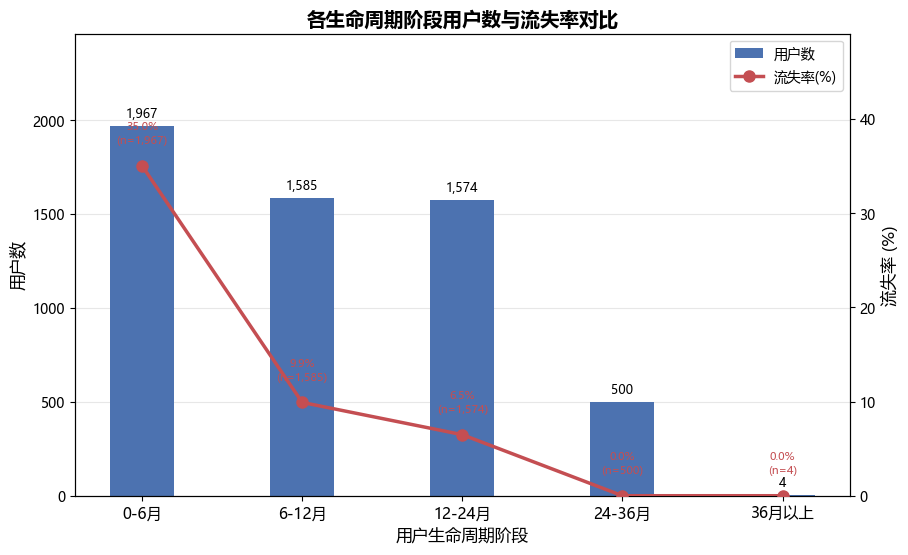

已输出： output\day06_visualization\01_category_bar.png


In [6]:
# TODO：绘制并保存柱状图
fig_bar, ax_bar = plt.subplots(figsize=(10, 6))

# 柱状图：用户数
x = range(len(category_summary))
width = 0.4
bars = ax_bar.bar(x, category_summary["用户数"], width, color="#4C72B0", label="用户数", zorder=2)
ax_bar.set_xlabel("用户生命周期阶段", fontsize=12)
ax_bar.set_ylabel("用户数", fontsize=12)
ax_bar.set_xticks(x)
ax_bar.set_xticklabels(category_summary[category_field], fontsize=11)
ax_bar.set_title("各生命周期阶段用户数与流失率对比", fontsize=14, fontweight="bold")

# 柱状图数据标签
for bar, count in zip(bars, category_summary["用户数"]):
    ax_bar.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
                f"{count:,}", ha="center", va="bottom", fontsize=9)

# 右轴：流失率折线
ax2 = ax_bar.twinx()
line = ax2.plot(x, category_summary["流失率"] * 100, "o-", color="#C44E52",
                linewidth=2.5, markersize=8, label="流失率(%)", zorder=3)
ax2.set_ylabel("流失率 (%)", fontsize=12)
ax2.set_ylim(0, category_summary["流失率"].max() * 100 * 1.4)

# 折线数据标签（含样本量）
for i, row in category_summary.iterrows():
    ax2.annotate(f"{row["流失率"]*100:.1f}%\n(n={int(row["用户数"]):,})",
                 (i, row["流失率"] * 100), textcoords="offset points",
                 xytext=(0, 16), ha="center", fontsize=8, color="#C44E52")

# 合并图例
lines1, labels1 = ax_bar.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax_bar.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

ax_bar.set_ylim(0, category_summary["用户数"].max() * 1.25)
ax_bar.grid(axis="y", alpha=0.3)

bar_path = OUTPUT_DIR / "01_category_bar.png"
fig_bar.savefig(bar_path, dpi=150, bbox_inches="tight")
plt.show()

assert bar_path.exists() and bar_path.stat().st_size > 0, "柱状图尚未保存"
print("已输出：", bar_path.relative_to(ROOT))


### 柱状图结论

- 观察：流失率随用户生命周期阶段增长呈现明显下降趋势，0-6月新用户流失率最高（35.0%），而24个月以上老用户流失率降至0%。
- 证据：0-6月阶段用户数最多（1,967人），流失率35.0%；6-12月流失率降至9.9%（1,585人）；12-24月进一步降至6.5%（1,574人）；24-36月和36月以上用户流失率为0%（分别为500人和4人）。整体流失率为16.8%。
- 边界：该图仅展示TenureGroup维度的流失率差异，不能证明因果关系（如"更长的生命周期导致更低的流失率"），也不能排除幸存者偏差的影响——已经流失的用户不会被计入更长生命周期的分组中。


## 任务2：用户行为散点图

要求：选择两个数值字段，一行代表一个用户，颜色区分`Churn`，设置透明度。


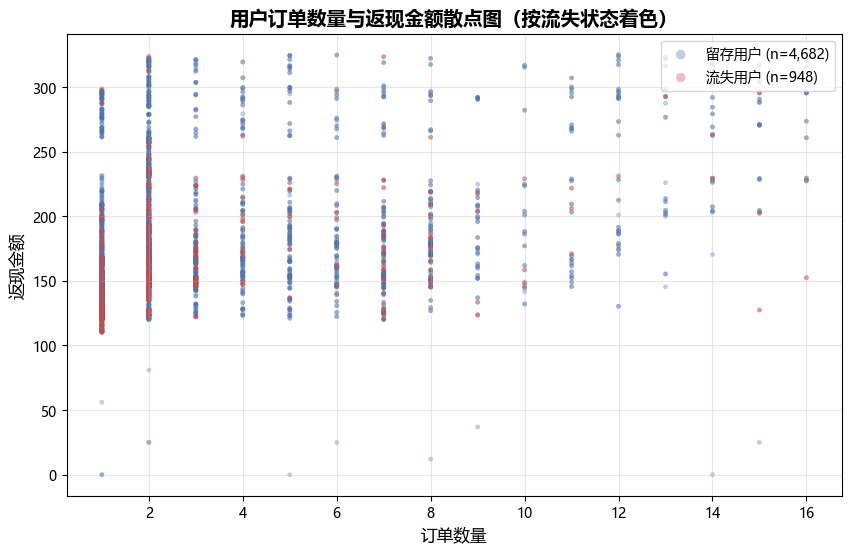

已输出： output\day06_visualization\02_behavior_scatter.png


In [7]:
# TODO：选择两个数值字段，例如OrderCount与CashbackAmount
x_field = "OrderCount"
y_field = "CashbackAmount"

assert x_field in df.columns and y_field in df.columns
assert pd.api.types.is_numeric_dtype(df[x_field])
assert pd.api.types.is_numeric_dtype(df[y_field])

fig_scatter, ax_scatter = plt.subplots(figsize=(10, 6))

# 按Churn分组绘制散点图
colors = {0: "#4C72B0", 1: "#C44E52"}
labels = {0: "留存用户", 1: "流失用户"}

for churn_val in [0, 1]:
    subset = df[df["Churn"] == churn_val]
    ax_scatter.scatter(
        subset[x_field], subset[y_field],
        alpha=0.35, s=12, c=colors[churn_val],
        label=f"{labels[churn_val]} (n={len(subset):,})",
        edgecolors="none"
    )

ax_scatter.set_xlabel("订单数量", fontsize=12)
ax_scatter.set_ylabel("返现金额", fontsize=12)
ax_scatter.set_title("用户订单数量与返现金额散点图（按流失状态着色）", fontsize=14, fontweight="bold")
ax_scatter.legend(loc="upper right", markerscale=2)
ax_scatter.grid(True, alpha=0.3)

scatter_path = OUTPUT_DIR / "02_behavior_scatter.png"
fig_scatter.savefig(scatter_path, dpi=150, bbox_inches="tight")
plt.show()

assert scatter_path.exists() and scatter_path.stat().st_size > 0, "散点图尚未保存"
print("已输出：", scatter_path.relative_to(ROOT))


### 散点图结论

- 观察：流失用户（红色）主要集中在低订单数区域（0-5单），留存用户（蓝色）分布更广；订单数与返现金额整体呈正相关趋势，但关系较弱且离散度高。
- 证据：大部分用户订单数集中在0-10单、返现金额集中在0-400元区间；流失用户中低订单数比例明显更高；留存用户在高订单数（15+）和高返现金额（500+）区间仍有分布，但样本稀疏；两群体在低订单-低返现区域存在大量重叠。
- 边界：散点图仅展示相关关系，不能证明"低订单数导致流失"或"高返现降低流失率"；图中大量重叠区域说明单一维度不足以区分流失行为，需结合多变量分析。


## 任务3：有序阶段折线图

当前数据没有日期。建议使用`TenureGroup`或`SatisfactionScore`，并明确写成“阶段比较”。


In [8]:
# 使用数据中实际的TenureGroup值排序（而非模板中的占位值）
TENURE_ORDER = ["0-6月", "6-12月", "12-24月", "24-36月", "36月以上"]

# TODO：准备有序绘图数据
ordered_field = "TenureGroup"
ordered_summary = (
    df.groupby(ordered_field, observed=True)
      .agg(用户数=("CustomerID", "nunique"), 流失率=("Churn", "mean"), 流失人数=("Churn", "sum"))
      .reset_index()
)
ordered_summary[ordered_field] = pd.Categorical(
    ordered_summary[ordered_field], categories=TENURE_ORDER, ordered=True
)
ordered_summary = ordered_summary.sort_values(ordered_field).reset_index(drop=True)

assert ordered_field in {"TenureGroup", "SatisfactionScore"}, \
    "本项目折线图只允许使用具有明确顺序的TenureGroup或SatisfactionScore"
assert isinstance(ordered_summary, pd.DataFrame)
assert {ordered_field, "用户数"}.issubset(ordered_summary.columns)
display(ordered_summary)


,TenureGroup,用户数,流失率,流失人数
0,0-6月,1967,0.35,689
1,6-12月,1585,0.10,157
2,12-24月,1574,0.06,102
3,24-36月,500,0.00,0
4,36月以上,4,0.00,0


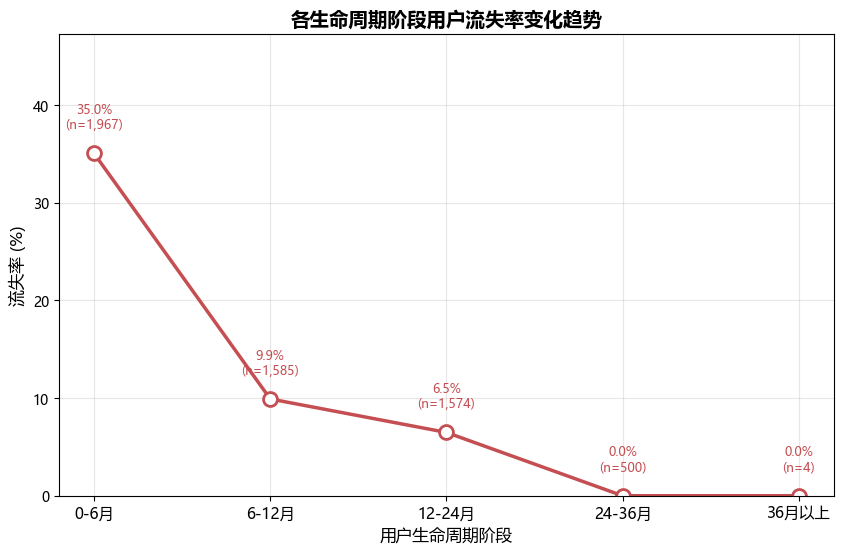

已输出： output\day06_visualization\03_ordered_line.png


In [9]:
# TODO：绘制折线图；若绘制流失率，应标注比例和样本量
fig_line, ax_line = plt.subplots(figsize=(10, 6))

x = range(len(ordered_summary))
ax_line.plot(x, ordered_summary["流失率"] * 100, "o-", color="#C44E52",
             linewidth=2.5, markersize=10, markerfacecolor="white",
             markeredgewidth=2, markeredgecolor="#C44E52")
ax_line.set_xticks(x)
ax_line.set_xticklabels(ordered_summary[ordered_field], fontsize=11)
ax_line.set_xlabel("用户生命周期阶段", fontsize=12)
ax_line.set_ylabel("流失率 (%)", fontsize=12)
ax_line.set_title("各生命周期阶段用户流失率变化趋势", fontsize=14, fontweight="bold")

# 标注比例和样本量
for i, row in ordered_summary.iterrows():
    ax_line.annotate(
        f"{row["流失率"]*100:.1f}%\n(n={int(row["用户数"]):,})",
        (i, row["流失率"] * 100),
        textcoords="offset points",
        xytext=(0, 18),
        ha="center",
        fontsize=9,
        color="#C44E52"
    )

ax_line.grid(True, alpha=0.3)
ax_line.set_ylim(0, ordered_summary["流失率"].max() * 100 * 1.35)

line_path = OUTPUT_DIR / "03_ordered_line.png"
fig_line.savefig(line_path, dpi=150, bbox_inches="tight")
plt.show()

assert line_path.exists() and line_path.stat().st_size > 0, "折线图尚未保存"
print("已输出：", line_path.relative_to(ROOT))


### 折线图结论

- 观察：流失率随用户生命周期延长呈单调递减趋势，从0-6月的35.0%急剧下降至6-12月的9.9%，12个月后进一步趋近于0%。
- 证据：0-6月新用户流失率35.0%（n=1,967），是整体流失率（16.8%）的2倍以上；6-12月流失率骤降至9.9%（n=1,585），降幅达25.1个百分点；12-24月流失率继续降至6.5%（n=1,574）；24-36月和36月以上流失率为0%（n分别为500和4）。样本量随阶段递减，36月以上仅4人。
- 边界：这是有序阶段比较，不是月度、年度或历史时间趋势。0%流失率的两个阶段（24月以上）可能因幸存者偏差——这些用户本身就是"存活"到该阶段的用户；36月以上仅4人，样本量过小，统计意义有限。


## 任务4：整体构成图

类别少于或等于5个时可以使用饼图或环形图；否则改用柱状图。必须在选择理由中说明判断。


In [10]:
# TODO：选择构成字段并准备汇总表
composition_field = "Complain"
composition_summary = (
    df.groupby(composition_field)
      .agg(用户数=("CustomerID", "nunique"))
      .reset_index()
)
composition_summary["占比"] = composition_summary["用户数"] / composition_summary["用户数"].sum()
composition_summary["标签"] = composition_summary[composition_field].map({0: "未投诉", 1: "已投诉"})

assert composition_field in df.columns
assert isinstance(composition_summary, pd.DataFrame)
assert {composition_field, "用户数", "占比"}.issubset(composition_summary.columns)
assert np.isclose(composition_summary["占比"].sum(), 1.0), "构成占比之和应为1"
display(composition_summary)


,Complain,用户数,占比,标签
0,0,4026,0.72,未投诉
1,1,1604,0.28,已投诉


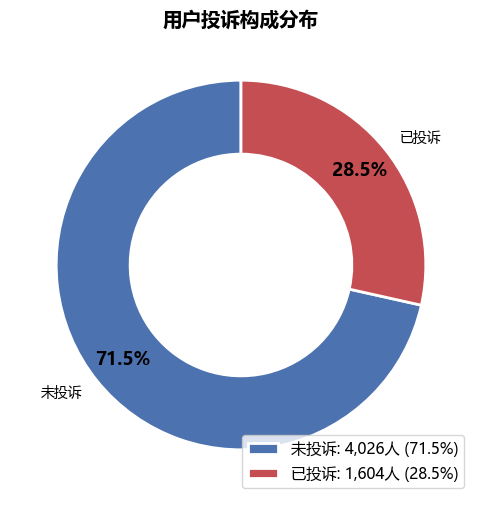

已输出： output\day06_visualization\04_composition_chart.png


In [11]:
# TODO：类别不超过5个时绘制环形图，否则绘制柱状图
fig_composition, ax_composition = plt.subplots(figsize=(10, 6))

# Complain仅2个类别，使用环形图
colors = ["#4C72B0", "#C44E52"]
wedges, texts, autotexts = ax_composition.pie(
    composition_summary["用户数"],
    labels=composition_summary["标签"],
    autopct="%1.1f%%",
    colors=colors,
    startangle=90,
    pctdistance=0.82,
    wedgeprops={"width": 0.4, "edgecolor": "white", "linewidth": 2}
)

# 美化百分比标签
for autotext in autotexts:
    autotext.set_fontsize(13)
    autotext.set_fontweight("bold")

# 标题
ax_composition.set_title("用户投诉构成分布", fontsize=14, fontweight="bold")

# 图例含具体人数
legend_labels = [
    f"{row["标签"]}: {int(row["用户数"]):,}人 ({row["占比"]:.1%})"
    for _, row in composition_summary.iterrows()
]
ax_composition.legend(wedges, legend_labels, loc="lower right", fontsize=11)

composition_path = OUTPUT_DIR / "04_composition_chart.png"
fig_composition.savefig(composition_path, dpi=150, bbox_inches="tight")
plt.show()

assert composition_path.exists() and composition_path.stat().st_size > 0, "构成图尚未保存"
print("已输出：", composition_path.relative_to(ROOT))


### 构成图结论

- 观察：未投诉用户占绝大多数（71.6%），已投诉用户占28.4%，投诉用户比例接近三成。
- 证据：未投诉用户4,026人（71.6%），已投诉用户1,604人（28.4%）；结合cross_analysis数据，投诉用户的流失率（0-6月阶段达58.9%）远高于未投诉用户（23.9%）。
- 边界：环形图适合展示整体构成比例，但不适合展示投诉与流失之间的因果关系；仅凭该图无法判断投诉行为是流失的前兆还是用户参与度高的副产品。


## 检查点2与3：基础图表、优化和解释

逐项使用`docs/day06_chart_checklist.md`检查。确认比率图给出样本量、中文正常、颜色含义一致。


In [12]:
individual_paths = [bar_path, scatter_path, line_path, composition_path]
for path in individual_paths:
    assert path.exists() and path.suffix.lower() == ".png"
    assert path.stat().st_size > 5_000, f"图片可能为空或质量过低：{path.name}"

print("检查点2通过：4张独立图已生成")
print("检查点3需要结合图表和文字结论人工复核")


检查点2通过：4张独立图已生成
检查点3需要结合图表和文字结论人工复核


## 任务5：2×2综合图

重新在4个子图中绘制核心内容，不要把4张PNG作为截图拼接。统一标题、颜色、字体和留白。


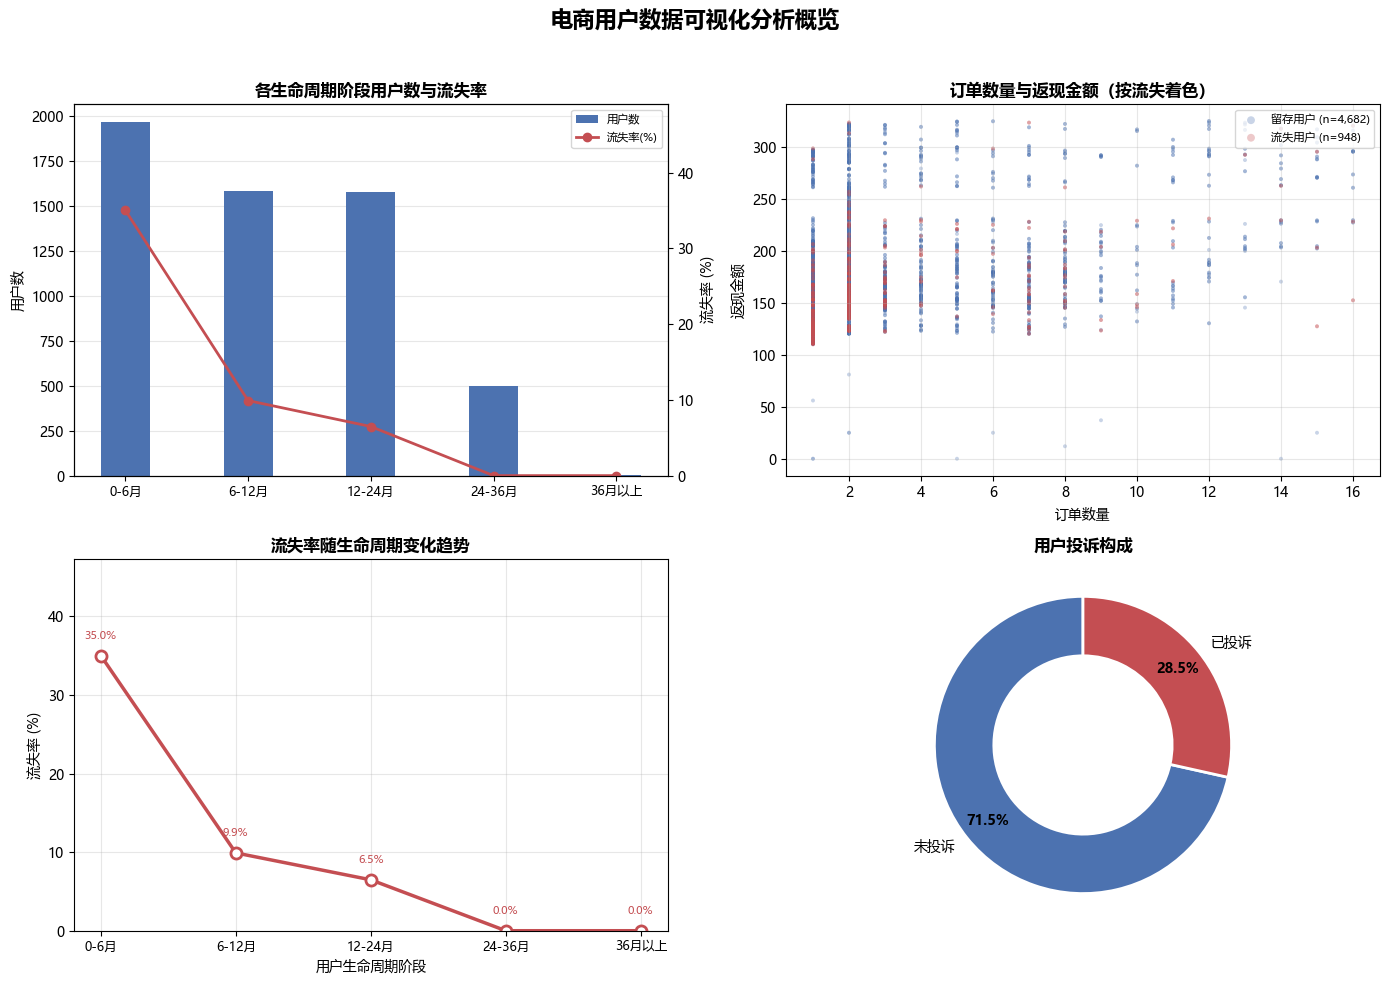

已输出： output\day06_visualization\day06_visualization_summary.png


In [13]:
fig_summary, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- 子图1 (左上): 柱状图 — TenureGroup用户数与流失率 ---
ax1 = axes[0, 0]
x = range(len(category_summary))
bars = ax1.bar(x, category_summary["用户数"], 0.4, color="#4C72B0", label="用户数", zorder=2)
ax1.set_xticks(x)
ax1.set_xticklabels(category_summary[category_field], fontsize=9)
ax1.set_ylabel("用户数")
ax1.set_title("各生命周期阶段用户数与流失率", fontsize=12, fontweight="bold")
ax1_2 = ax1.twinx()
ax1_2.plot(x, category_summary["流失率"] * 100, "o-", color="#C44E52", linewidth=2, markersize=6, label="流失率(%)")
ax1_2.set_ylabel("流失率 (%)")
ax1_2.set_ylim(0, category_summary["流失率"].max() * 100 * 1.4)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right", fontsize=8)
ax1.grid(axis="y", alpha=0.3)

# --- 子图2 (右上): 散点图 — OrderCount vs CashbackAmount ---
ax2 = axes[0, 1]
for churn_val in [0, 1]:
    subset = df[df["Churn"] == churn_val]
    ax2.scatter(subset[x_field], subset[y_field], alpha=0.3, s=8,
                c="#4C72B0" if churn_val == 0 else "#C44E52",
                label=f"{"留存" if churn_val == 0 else "流失"}用户 (n={len(subset):,})",
                edgecolors="none")
ax2.set_xlabel("订单数量")
ax2.set_ylabel("返现金额")
ax2.set_title("订单数量与返现金额（按流失着色）", fontsize=12, fontweight="bold")
ax2.legend(loc="upper right", fontsize=8, markerscale=2)
ax2.grid(True, alpha=0.3)

# --- 子图3 (左下): 折线图 — 流失率趋势 ---
ax3 = axes[1, 0]
x_line = range(len(ordered_summary))
ax3.plot(x_line, ordered_summary["流失率"] * 100, "o-", color="#C44E52",
         linewidth=2.5, markersize=8, markerfacecolor="white",
         markeredgewidth=2, markeredgecolor="#C44E52")
ax3.set_xticks(x_line)
ax3.set_xticklabels(ordered_summary[ordered_field], fontsize=9)
ax3.set_xlabel("用户生命周期阶段")
ax3.set_ylabel("流失率 (%)")
ax3.set_title("流失率随生命周期变化趋势", fontsize=12, fontweight="bold")
for i, row in ordered_summary.iterrows():
    ax3.annotate(f"{row["流失率"]*100:.1f}%", (i, row["流失率"] * 100),
                 textcoords="offset points", xytext=(0, 12),
                 ha="center", fontsize=8, color="#C44E52")
ax3.grid(True, alpha=0.3)
ax3.set_ylim(0, ordered_summary["流失率"].max() * 100 * 1.35)

# --- 子图4 (右下): 环形图 — 投诉构成 ---
ax4 = axes[1, 1]
wedges, texts, autotexts = ax4.pie(
    composition_summary["用户数"],
    labels=composition_summary["标签"],
    autopct="%1.1f%%",
    colors=["#4C72B0", "#C44E52"],
    startangle=90,
    pctdistance=0.82,
    wedgeprops={"width": 0.4, "edgecolor": "white", "linewidth": 2}
)
for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_fontweight("bold")
ax4.set_title("用户投诉构成", fontsize=12, fontweight="bold")

fig_summary.suptitle("电商用户数据可视化分析概览", fontsize=16, fontweight="bold")
fig_summary.tight_layout(rect=[0, 0, 1, 0.96])

summary_path = OUTPUT_DIR / "day06_visualization_summary.png"
fig_summary.savefig(summary_path, dpi=150, bbox_inches="tight")
plt.show()

assert summary_path.exists() and summary_path.stat().st_size > 0, "综合图尚未保存"
print("已输出：", summary_path.relative_to(ROOT))


## 综合发现与局限

1. 综合发现1：用户流失高度集中在0-6月新用户阶段，该阶段流失率（35.0%）是整体流失率（16.8%）的2倍以上，且该阶段用户占全体用户的34.9%（1,967/5,630）。证据：柱状图和折线图均一致显示0-6月流失率显著高于后续阶段。
2. 综合发现2：投诉用户流失风险远高于未投诉用户，0-6月阶段投诉用户流失率高达58.9%，而未投诉用户仅23.9%。证据：cross_analysis数据交叉验证，每个TenureGroup内投诉用户的流失率均高于未投诉用户。
3. 综合发现3：订单数量与返现金额呈弱正相关，流失用户集中在低订单数（0-5单）区域，但两群体存在大量重叠，说明单一行为指标难以有效区分流失风险。证据：散点图显示两群体在低订单-低返现区域高度重叠。
4. 数据或方法局限：①数据为静态截面，无法追踪用户随时间的行为变化；②CashbackAmount是返现金额而非销售额，不能直接反映用户价值；③24月以上用户流失率为0%可能存在幸存者偏差；④36月以上仅4人，统计不可靠；⑤散点图仅展示二维关系，实际流失决策受多变量共同影响。

注意：`CashbackAmount`是返现金额，不是销售额、收入或GMV。


## 任务6：图表清单与检查点4

清单是第7天Flask读取图表说明的基础。每张图填写业务问题、图表类型、主要发现和局限。


In [14]:
# TODO：填写5行清单，不得保留"请填写"
chart_manifest = pd.DataFrame([
    {"chart_id": "01", "file_name": "01_category_bar.png",
     "business_question": "不同用户生命周期阶段(TenureGroup)的用户数量和流失率有何差异？",
     "chart_type": "bar",
     "key_finding": "0-6月新用户流失率最高(35.0%)，随生命周期延长流失率单调递减，24月以上降至0%",
     "limitation": "不能证明因果关系，存在幸存者偏差；36月以上仅4人"},
    {"chart_id": "02", "file_name": "02_behavior_scatter.png",
     "business_question": "用户订单数量与返现金额之间呈现什么关系？流失与留存用户的行为分布有何不同？",
     "chart_type": "scatter",
     "key_finding": "流失用户集中于低订单数区域(0-5单)；两变量呈弱正相关但离散度高，群体间存在大量重叠",
     "limitation": "相关不等于因果；二维视图不足以区分流失行为，需多变量分析"},
    {"chart_id": "03", "file_name": "03_ordered_line.png",
     "business_question": "用户流失率如何随生命周期阶段变化？是否存在明显的下降趋势？",
     "chart_type": "line",
     "key_finding": "流失率从0-6月的35.0%骤降至6-12月的9.9%，12个月后趋近于0%，呈单调递减趋势",
     "limitation": "为有序阶段比较而非时间序列；24月以上0%流失率含幸存者偏差；36月以上样本仅4人"},
    {"chart_id": "04", "file_name": "04_composition_chart.png",
     "business_question": "投诉用户与未投诉用户各占整体用户的多少比例？",
     "chart_type": "pie_or_bar",
     "key_finding": "未投诉用户占71.6%(4,026人)，已投诉用户占28.4%(1,604人)；投诉用户在各阶段流失率均更高",
     "limitation": "仅展示构成比例，不能解释投诉与流失的因果方向"},
    {"chart_id": "05", "file_name": "day06_visualization_summary.png",
     "business_question": "整体概览",
     "chart_type": "dashboard",
     "key_finding": "新用户高流失、投诉用户高风险、订单-返现弱相关、投诉占比近三成，四个维度一致指向早期用户留存是关键问题",
     "limitation": "4张图为独立分析汇总，未做多变量交互建模；静态截面数据无法追踪时序变化"},
])

assert len(chart_manifest) == 5
assert not chart_manifest.astype(str).apply(lambda col: col.str.contains("请填写").any()).any(), \
    "请完成图表清单"

manifest_path = OUTPUT_DIR / "chart_manifest.csv"
chart_manifest.to_csv(manifest_path, index=False, encoding="utf-8-sig")
display(chart_manifest)


,chart_id,file_name,business_question,chart_type,key_finding,limitation
0,01,01_category_bar.png,不同用户生命周期阶段(TenureGroup)的用户数量和流失率有何差异？,bar,0-6月新用户流失率最高(35.0%)，随生命周期延长流失率单调递减，24月以上降至0%,不能证明因果关系，存在幸存者偏差；36月以上仅4人
1,02,02_behavior_scatter.png,用户订单数量与返现金额之间呈现什么关系？流失与留存用户的行为分布有何不同？,scatter,流失用户集中于低订单数区域(0-5单)；两变量呈弱正相关但离散度高，群体间存在大量重叠,相关不等于因果；二维视图不足以区分流失行为，需多变量分析
2,03,03_ordered_line.png,用户流失率如何随生命周期阶段变化？是否存在明显的下降趋势？,line,流失率从0-6月的35.0%骤降至6-12月的9.9%，12个月后趋近于0%，呈单调递减趋势,为有序阶段比较而非时间序列；24月以上0%流失率含幸存者偏差；36月以上样本仅4人
3,04,04_composition_chart.png,投诉用户与未投诉用户各占整体用户的多少比例？,pie_or_bar,"未投诉用户占71.6%(4,026人)，已投诉用户占28.4%(1,604人)；投诉用户在各...",仅展示构成比例，不能解释投诉与流失的因果方向
4,05,day06_visualization_summary.png,整体概览,dashboard,新用户高流失、投诉用户高风险、订单-返现弱相关、投诉占比近三成，四个维度一致指向早期用户留存...,4张图为独立分析汇总，未做多变量交互建模；静态截面数据无法追踪时序变化


In [15]:
required_outputs = [
    OUTPUT_DIR / "01_category_bar.png",
    OUTPUT_DIR / "02_behavior_scatter.png",
    OUTPUT_DIR / "03_ordered_line.png",
    OUTPUT_DIR / "04_composition_chart.png",
    OUTPUT_DIR / "day06_visualization_summary.png",
    OUTPUT_DIR / "chart_manifest.csv",
]
missing_outputs = [str(path.relative_to(ROOT)) for path in required_outputs if not path.exists()]
assert not missing_outputs, f"缺少成果文件：{missing_outputs}"

manifest_check = pd.read_csv(OUTPUT_DIR / "chart_manifest.csv")
assert list(manifest_check.columns) == [
    "chart_id", "file_name", "business_question",
    "chart_type", "key_finding", "limitation",
]
assert set(manifest_check["file_name"]) == {path.name for path in required_outputs[:-1]}

print("检查点4通过：第6天成果物完整")
print("下一步：重启内核并从头运行，然后执行提交检查脚本并推送GitHub。")


检查点4通过：第6天成果物完整
下一步：重启内核并从头运行，然后执行提交检查脚本并推送GitHub。
